# PTI-Clima Notebooks  <img src="https://www.r-project.org/logo/Rlogo.png" alt="Description" width="60" height="40">

***

> Este cuaderno o notebook muestra LO QUE MUESTRE EL NOTEBOOK utilizando los conjuntos de datos de la PTI-Clima que se incluyen en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)


## Guía para el uso del dataset: PTI-grid-v0

**M. Fuente-González** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

**¡Bienvenidos al cuaderno "Guía para el uso del dataset: PTI-grid-v0_Iberia_day" de la Plataforma Virtual de Cálculo de la PTI-Clima!**  
Esta guía tiene como objetivo ayudarte a entender y cargar el dataset PTI-grid-v0_Iberia_day, de manera que puedas sacar el máximo provecho de estos datos disponibles en el [**Almacén de Datos de la PTI-Clima**](https://pti.climate.ifca.es/data). A través de esta plataforma, podrás realizar investigaciones y **análisis climáticos de relevancia**, ya que ofrece **acceso transparente a una amplia gama de materiales y datos** subyacentes a los **servicios climáticos desarrollados en la PTI-Clima**, fomentando su **reutilización** y posibilitando la **reproducibilidad** de los productos generados.

En concreto, esta guía pretende ayudarte a entender como cargar diferentes datasets para us
ar las diferentes variables en diferentes tipos de estudios, ya sea el cálculo de índices, análisis climáticos, etc. El objetivo principal es que comprendas de forma general la carga de datos y que puedas llevarlo a cabo en tus propias investigaciones. Se trata de un cuaderno que contiene conceptos básicos para poder entender y reproducir otros de manera más autodidácta. De esta manera vamos a **guiarte** a través de los pasos fundamentales para trabajar de manera efectiva con los datos este tipo de daatasets.

Tras la carga de datos, habrá bloques de visualizaciones, permitiendo familiarizarte con este tipo de análisis de resultados y permitiendote aprender diferentes tipos de representacionse. Para todo ello, se utilizará el **framework *climate4R***, un conjunto de librerías de R para la carga, post-procesamiento y análisis de datos climáticos. 


<img src="https://raw.githubusercontent.com/SantanderMetGroup/climate4R/refs/heads/devel/man/figures/climate4R_logo.svg" alt="Description" width="60" height="40">

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo de índices**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

### Contenido de este cuaderno
1) Carga de librerías
2) Selección de conjuntos de datos  
3) Carga de datos
4) Análisis básico
   * 4.1. Medias climatológicas
   * 4.2. Percentiles
   * 4.3. Índices
   * 4.4. Precipitación
   * 4.5. Series temporales

Empezamos dando la memoria que queramos a la RAM (la suficiente para poder cargar varios variables)

In [1]:
options(java.parameters = "-Xmx32g")

### 1. Carga de librerías

Cargamos las librerías necesarias, que corresponden a librerías del framework *climate4R* y van a permitir cargar datos, transformarlos, usar índices y visualizarlos.

In [2]:
library(loadeR)
library(transformeR)
library(climate4R.indices)
library(visualizeR)

Loading required package: rJava

Loading required package: loadeR.java

Java version 22x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.3) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

climate4R.indices version 0.3.1 (2023-06-22) is loaded

Use 'indexShow()' for an overview of the available climate indices and circIndexShow() for the circulation indices.

NOTE: use package climate4R.climdex to calculate ETCCDI indices.


Attaching package: ‘climate4R.indices’


The following object is masked from ‘package:transformeR’:

    lambWT


visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



### 2. Selección de conjuntos de datos  

Leemos el archivo donde se tiene el contenido de todos los datasets y vemos que pinta tiene para decidir que es lo que queremos cargar.

In [3]:
df <- read.csv("../data_inventory.csv")

In [4]:
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-5KM-regular_Iberia_day,observations,opendap,AEMET-5KM-regular,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-5KM-regular/Iberia/day/AEMET-5KM-regular_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-5KM-regular.dic
2,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Canarias/day/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
3,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Iberia/day/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Canarias/day/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
5,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v1_Canarias_day,observations,opendap,PTI-grid-v1,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v1/Canarias/day/PTI-grid-v1_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic


En este caso, vamos a cargar el dataset de PTI-clima-v0. Para ello, mostramos el subconjunto de los datasets que corresponden con *"PTI-grid-v0"*. Hay dataset para la Península Ibérica (PI) y para las Islas Canarias.

In [5]:
subset(df, source == "PTI-grid-v0")

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
4,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Canarias/day/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
5,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic


### 3. Carga de datos

##### Trabajamos con observaciones de la Península Ibérica

Tras ver los posibles datasets de observaciones correspondientes al dataset PTI-grid-v0, vamos a cargar el correspondiente a los datos de la Penínusla Ibérica.

Primero llamamos al dataset concreto que queremos analizar, apuntando con el sufijo *endpoint*, a la url que queremos referirnos. A continuación, hacemos un inventario para saber que variables tiene el dataset y en que unidades están.

In [6]:
subset.pi <- subset(df, dataset == "PTI-grid-v0_Iberia_day")
lon.pi <- as.character(subset.pi$endpoint)
obs.pi <- dataInventory(lon.pi)

[2025-09-23 11:05:08.26802] Doing inventory ...

[2025-09-23 11:05:08.461237] Opening dataset...

[2025-09-23 11:05:09.6312] The dataset was successfuly opened

[2025-09-23 11:05:09.739642] Retrieving info for 'pr' (4 vars remaining)

[2025-09-23 11:05:09.865609] Retrieving info for 'hr' (3 vars remaining)

[2025-09-23 11:05:09.955914] Retrieving info for 'tmin' (2 vars remaining)

[2025-09-23 11:05:10.025479] Retrieving info for 'tdew' (1 vars remaining)

[2025-09-23 11:05:10.144833] Retrieving info for 'tmax' (0 vars remaining)

[2025-09-23 11:05:10.21383] Done.



In [7]:
str(obs.pi)

List of 5
 $ pr  :List of 7
  ..$ Description: chr "Precipitation"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 22645 341 545
  ..$ Units      : chr "mm"
  ..$ DataSizeMb : num 16834
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time:List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1961-01-01"
  .. .. ..$ Date_range: chr "1961-01-01T00:00:00Z - 2022-12-31T00:00:00Z"
  .. ..$ lat :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:341] 35.3 35.3 35.3 35.4 35.4 ...
  .. .. ..$ Shape      : int 341
  .. .. ..$ Coordinates: chr "lat"
  .. ..$ lon :List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:545] -9.29 -9.26 -9.24 -9.21 -9.19 ...
  .. .. ..$ Shape      : int 545
  .. .. ..$ Coordinates: chr "lon"
 $ hr  :List of 7
  ..$ Description: chr "R

Vamos a cargar la temperatura máxima diaria, como se puede ver al hacer el inventario, hay que referirse a ella como *tmax*. De todo el posible periodo que se tiene (1961-2022) vamos a cargar una región en específico (correspondiente a la parte norte de la Península Ibérica) y el periodo desde el 2000 al 2010.

In [8]:
tasmax.pi <- loadGridData(dataset = lon.pi,
                           var = "tmax",
                           lonLim=c(-7.4,-2.7),
                           latLim=c(41.9, 43.9),
                           years=2000:2010)

[2025-09-23 11:05:10.444847] Opening dataset...

[2025-09-23 11:05:10.540353] The dataset was successfuly opened

[2025-09-23 11:05:10.546207] Defining geo-location parameters

[2025-09-23 11:05:10.622303] Defining time selection parameters

[2025-09-23 11:05:10.820537] Retrieving data subset ...

[2025-09-23 11:05:50.731551] Done



Volvemos a llamar a la funcion *str* para ver la pinta que tiene la temperatura máxima, con esto podemos ver la resolución del dataset y las unidades (en caso de no habernos fijado antes)

In [9]:
str(tasmax.pi)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "tmax"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi FALSE
  ..- attr(*, "description")= chr "Maximum temperature"
  ..- attr(*, "units")= chr "grades celsius"
  ..- attr(*, "longname")= chr "tmax"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "none"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:4018, 1:77, 1:189] 9.23 9.52 8.2 7.19 6.46 ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:189] -7.39 -7.36 -7.34 -7.31 -7.29 ...
  ..$ y: num [1:77] 41.9 41.9 41.9 42 42 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.025
  ..- attr(*, "resY")= num 0.025
 $ Dates   :List of 2
  ..$ start: chr [1:4018] "2000-01-01 00:00:00 GMT" "2000-01-02 00:00:00 GMT" "2000-01-03 00:00:00 GMT" "2000-01-04 00:00:00 GMT" ...
  ..$ end  : chr [1:4018] "2000-01-01 00:00:00 GMT" "2000-01-02 00:00:00 GM

Podemos observar, que este dataset corresponde con la temperatura máxima y en el atributo "units" vemos que está en grados Celsius. Tiene una resolución de 0.025, es decir de unos 25 km aproximadamente y los datos son diarios. Como se ha elegido un un periodo concreto de tiempo (de 2000 a 2010) y de espacio (latitud de 41.9 a 43.9 y longitud de -7.4 a -2.7), las dimensiones y tamaño corresponden con este subconjunto.

### 4. Análisis

#### 4.1. Media climatológica

Una vez tenemos el dataset cargado, pasamos a la parte de *visualización*. Para ello, una de las opciones es hacer una climatología y representarlo espacialmente. La función *spatialPlot*, permite realizar esta representación y dependiendo de los argumentos que se pasen, puedes modifcar el colorbar, añadir títulos, nombres a los ejes, etc.

[2025-09-23 11:05:51.624861] - Computing climatology...

[2025-09-23 11:05:53.87671] - Done.



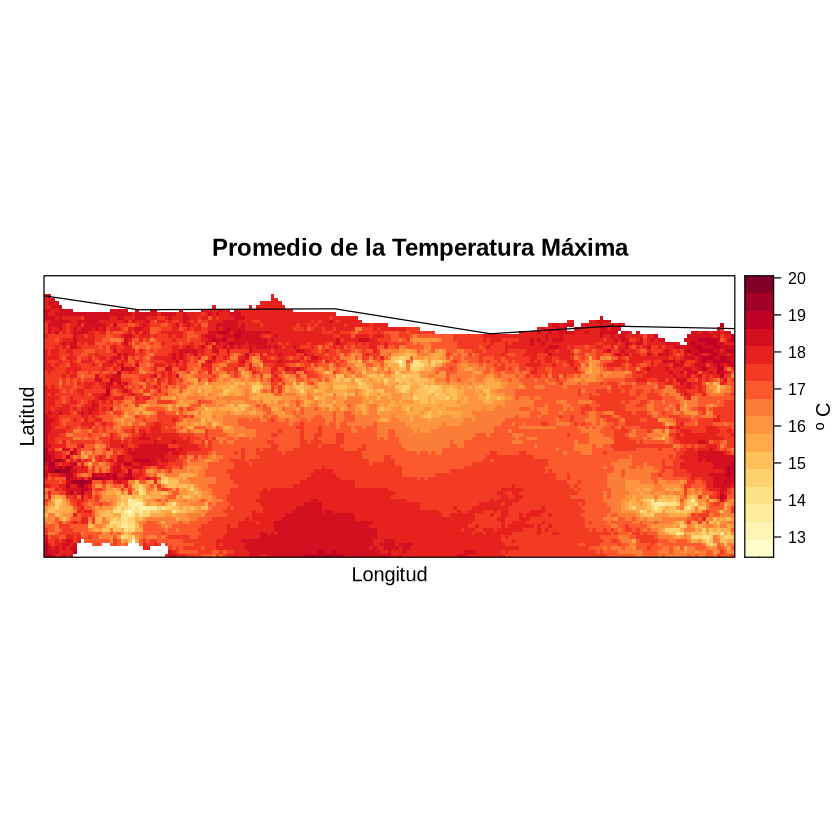

In [10]:
spatialPlot(climatology(tasmax.pi), main="Promedio de la Temperatura Máxima", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("º C", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
            )

#### 4.2. Percentiles

En vez del promedio, también podemos ver las colas de la distribución, como el percentil 90. Para ello, se le pasa a la función *climatology* dentro del argumento clim.fun lo que queremos que se haga.

In [11]:
p90.tmax <- climatology(tasmax.pi, clim.fun = list(FUN = "quantile", probs=0.90, na.rm=TRUE))

[2025-09-23 11:05:54.892832] - Computing climatology...

[2025-09-23 11:05:59.561035] - Done.



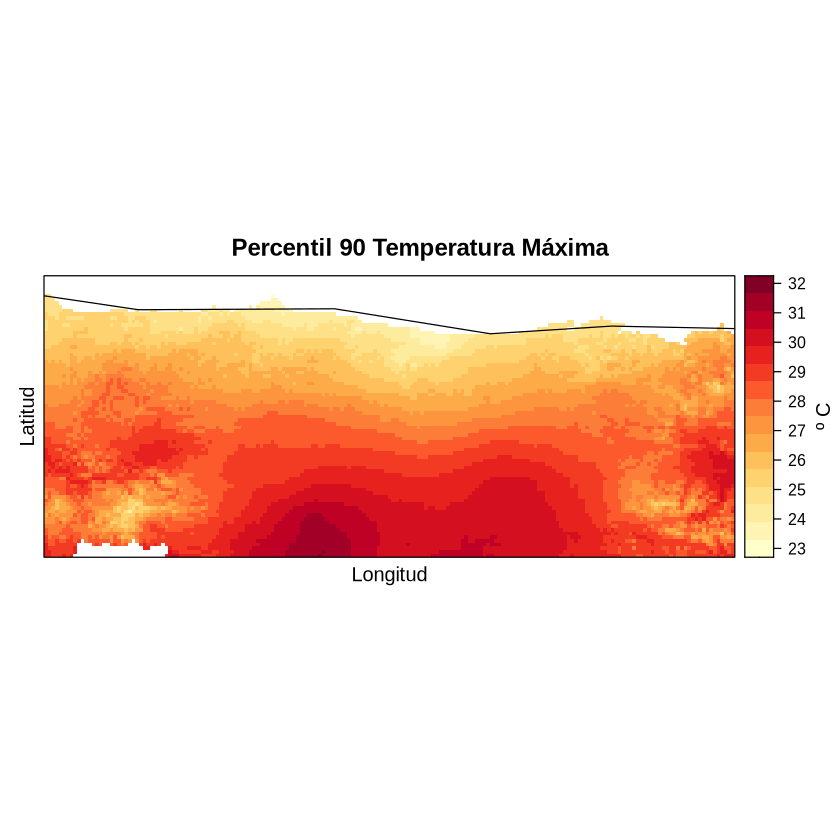

In [12]:
spatialPlot(p90.tmax, main="Percentil 90 Temperatura Máxima", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("º C", cex = 1)),
                            xlab = "Longitud",
                            ylab = "Latitud"
                           
            )

O el percentil 10.

In [13]:
p10.tmax <- climatology(tasmax.pi, clim.fun = list(FUN = "quantile", probs=0.10, na.rm=TRUE))

[2025-09-23 11:06:00.736943] - Computing climatology...

[2025-09-23 11:06:05.186228] - Done.



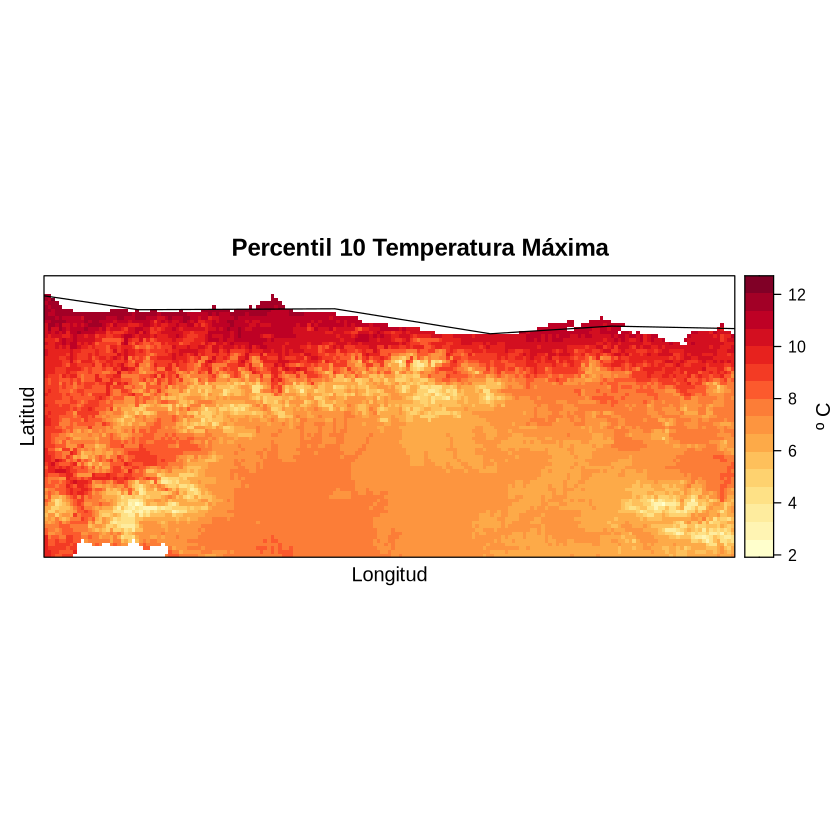

In [14]:
spatialPlot(p10.tmax, main="Percentil 10 Temperatura Máxima", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("º C", cex = 1)),
                            xlab = "Longitud",
                            ylab = "Latitud"
                           
            )

#### 4.3. Índices

Al igual que parámetros estadísticos, también podemos mirar índices. En este caso, vamos a ver cuántos días del año para cada gridbox hay por encima de la temperatura de 35 ºC. Para eso usamos la función *indexGrid*.

In [15]:
idx35 <- indexGrid(tx=tasmax.pi, index.code="TXth", th=35)

[2025-09-23 11:06:10.213887] Calculating TXth ...

[2025-09-23 11:06:16.223658] Done



In [16]:
sum.idx35 <- climatology(idx35, clim.fun = list(FUN = "sum"))

[2025-09-23 11:06:16.244655] - Computing climatology...

[2025-09-23 11:06:16.267571] - Done.



In [17]:
mask <- climatology(tasmax.pi)
mask$Data[!is.na(mask$Data)] <- 1

[2025-09-23 11:06:16.775305] - Computing climatology...

[2025-09-23 11:06:19.051472] - Done.



In [18]:
idx35.masked <- gridArithmetics(sum.idx35, mask, operator="*")

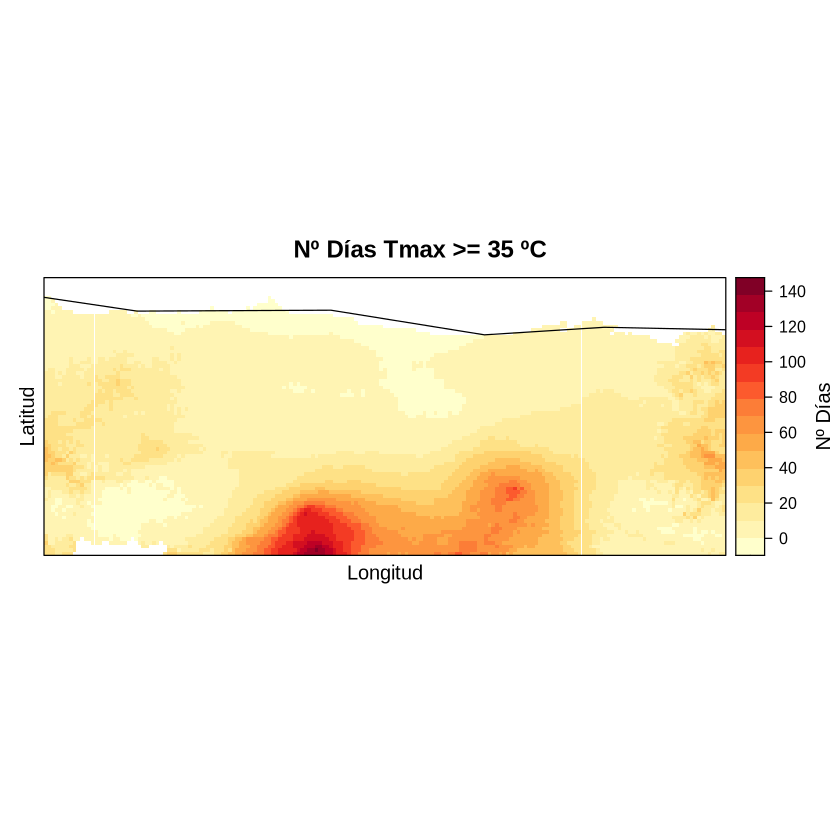

In [19]:
spatialPlot(idx35.masked, main="Nº Días Tmax >= 35 ºC", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("Nº Días", cex = 1)),
                            xlab = "Longitud",
                            ylab = "Latitud"
                           
            )

#### 4.4. Precipitación

No solo se puede cargar la variable de temperatura máxima. Como hemos visto antes al ver las variables del dataset, se tienen tiene temperatura mínima, humedad relativa, precipitación, etc. A continuación, cargaremos la precipitación, para ello nos referimos a ella como *pr*. Cargamos la misma región y el mismo periodo.

In [20]:
pr.pi <- loadGridData(dataset = lon.pi,
                           var = "pr",
                           lonLim=c(-7.4,-2.7),
                           latLim=c(41.9, 43.9),
                           years=2000:2010)

[2025-09-23 11:06:19.606986] Opening dataset...

[2025-09-23 11:06:19.723024] The dataset was successfuly opened

[2025-09-23 11:06:19.727856] Defining geo-location parameters

[2025-09-23 11:06:19.804877] Defining time selection parameters

[2025-09-23 11:06:19.971442] Retrieving data subset ...

[2025-09-23 11:06:48.665921] Done



Para proceder de forma distinta y ver otras funcionalidades del framework y como tratar el dataset vamos a hacer una agregación mensual.

In [21]:
pr.pi.aggr.m <- aggregateGrid(pr.pi, aggr.m=list(FUN="sum"))

[2025-09-23 11:06:49.351974] Performing monthly aggregation...

[2025-09-23 11:06:55.718133] Done.



Para una visualización espacial, recurrimos de nuevo a la función *spatialPlot*.

[2025-09-23 11:06:55.767272] - Computing climatology...

[2025-09-23 11:06:55.919915] - Done.



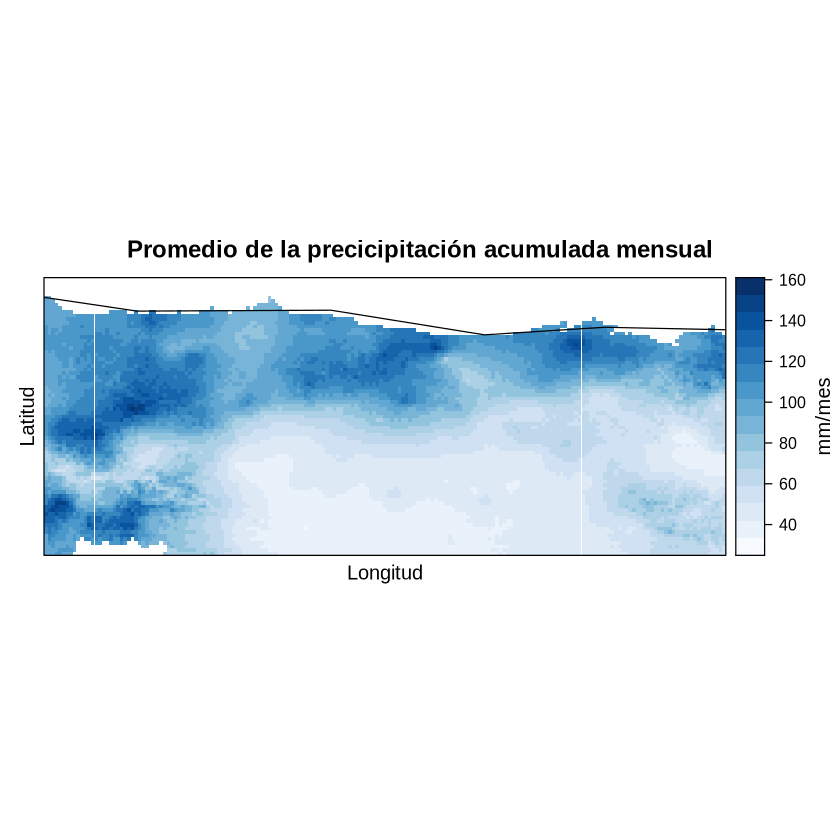

In [22]:
spatialPlot(climatology(pr.pi.aggr.m), main="Promedio de la precicipitación acumulada mensual", backdrop.theme="coastline", color.theme="Blues", 
            colorkey = list(space = "right",
                            title = list("mm/mes", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
            )

#### 4.5. Series temporales


Elegimos varios puntos de la región de la península cargada. Para ver las diferencias se escoge Burgos, Santander y Oviedo. De esta manera, al usar la función *subsetGrid*, nos quedamos unicamente con la latitud y longitud seleccionada.

In [23]:
burgos <- subsetGrid(pr.pi.aggr.m, latLim=42.3, lonLim=-3.7)
santander <- subsetGrid(pr.pi.aggr.m, latLim=43.5, lonLim=-3.8)
oviedo <- subsetGrid(pr.pi.aggr.m, latLim=43.3, lonLim=-5.8)

Usando la funcion *temporalGrid* podemos visualizar las series temporales de la precipitación acumulada mensual tanto para los gridboxes seleccionados, como para una media de toda la región cargada.

pad applied on the interval: month

pad applied on the interval: month

pad applied on the interval: month

pad applied on the interval: month



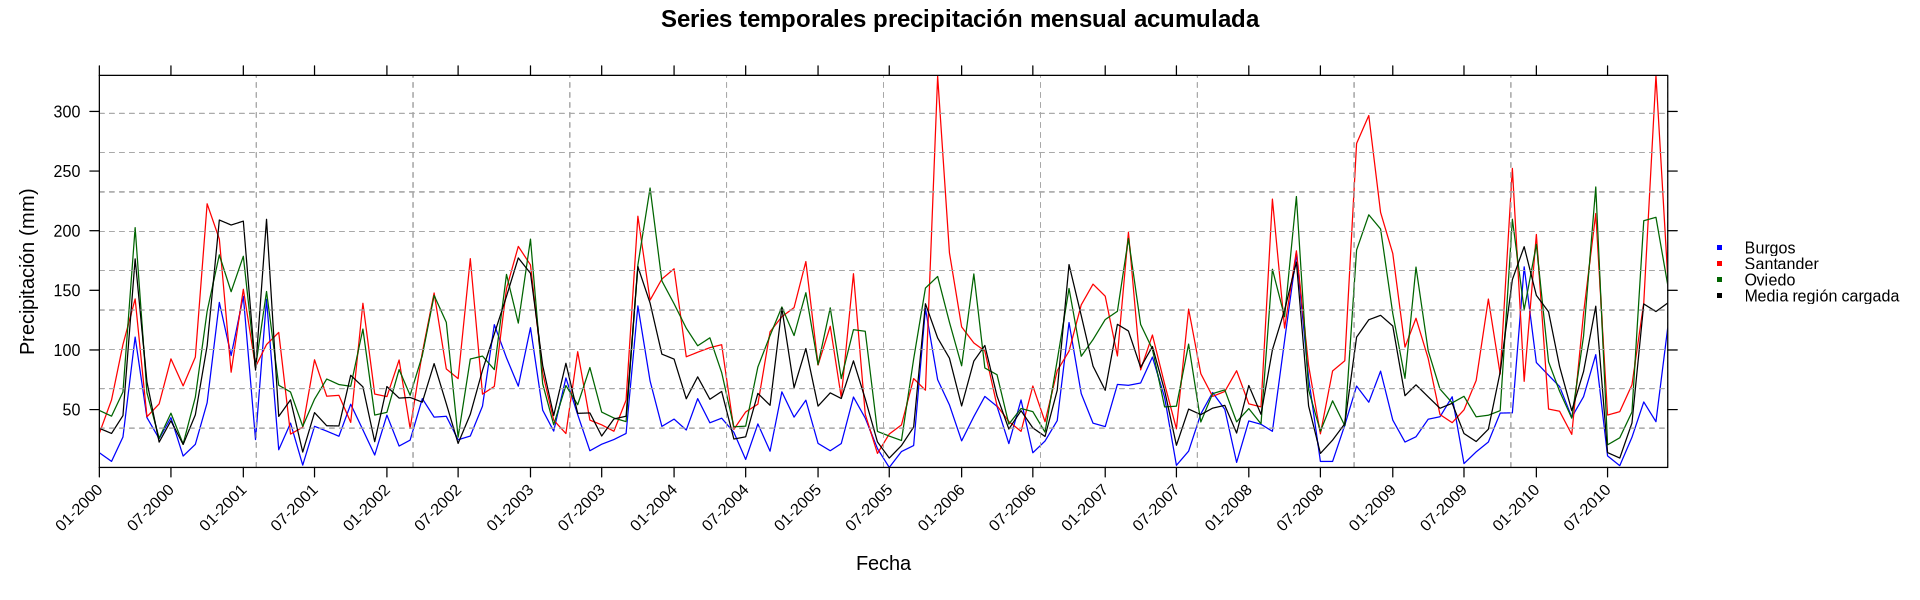

In [24]:
options(repr.plot.width = 16, repr.plot.height = 5)

temporalPlot("Burgos" = burgos,
             "Santander" = santander,
             "Oviedo" = oviedo,
             "Media región cargada" = pr.pi.aggr.m, 
             cols = c("blue", "red", "darkgreen", "black"),
             xyplot.custom = list(
               main = "Series temporales precipitación mensual acumulada",
               ylab = "Precipitación (mm)",
               xlab = "Fecha",
               scales = list(
                 x = list(
                   at = seq(min(as.Date(burgos$Dates$start)),
                            max(as.Date(burgos$Dates$start)),
                            by = "6 months"),
                   labels = format(
                     seq(min(as.Date(burgos$Dates$start)),
                         max(as.Date(burgos$Dates$start)),
                         by = "6 months"),
                     "%m-%Y"
                   ),
                   rot = 45
                 )
               )
             ))


In [25]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/climate4r/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_US.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=en_US.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=en_US.UTF-8          LC_NAME=en_US.UTF-8          
 [9] LC_ADDRESS=en_US.UTF-8        LC_TELEPHONE=en_US.UTF-8     
[11] LC_MEASUREMENT=en_US.UTF-8    LC_IDENTIFICATION=en_US.UTF-8

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] visualizeR_1.6.4        climate4R.indices_0.3.1 transformeR_2.2.2      
[4] loadeR_1.8.1            climate4R.UDG_0.2.6     loadeR.java_1.1.1      
[7] rJava_1.0-11           

loaded via a namespace 